<h2>Training a CNN on MNIST data</h2>

In [1]:
import torch
import random
import torchvision
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader

In [2]:
transform = transforms.Compose([    
    transforms.ToTensor()
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 3.30MB/s]
100%|███████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 486kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 7.00MB/s]


<h4>Split into training and validation data</h4>

In [3]:
trainSize = int(0.85 * len(trainset)) # Take 85% data for training and 15% for validation
valSize = len(trainset) - trainSize
trainData, valData = torch.utils.data.random_split(trainset, [trainSize, valSize])

In [4]:
trainLoader = torch.utils.data.DataLoader(trainData, batch_size=64, shuffle=True)
valLoader = torch.utils.data.DataLoader(valData, batch_size=64, shuffle=False)
testLoader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [5]:
print(f'Size of image : {trainData[0][0].shape}')

Size of image : torch.Size([1, 28, 28])


<h4>Define the LeNet model</h4>

[LeNet](https://en.wikipedia.org/wiki/LeNet)

In [6]:
numClasses = len(np.unique(trainset.targets))

In [8]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=0),
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=16*5*5, out_features=120),
    nn.Sigmoid(),
    nn.Linear(in_features=120, out_features=84),
    nn.Sigmoid(),
    nn.Linear(in_features=84, out_features=numClasses)
)

In [8]:
# Calculate dimension of output till the first FC layer
# That will be the number of input features for 1st FC hidden layer

# Or define a 1x28x28 tensor and find output dimension just before the FC layer
# In the code above take only the Conv + Pooling layers and find the output dimension

# x = torch.randn(1, 1, 28, 28)
# print(model(x).shape)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
trainLosses, valLosses = [], []
numEpochs = 50

In [10]:
for epoch in range(numEpochs):
    model.train()
    trainingLoss = 0
    numSamples = 0
    for images, labels in trainLoader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        batchSize = labels.size(0)
        trainingLoss += loss.item()*batchSize
        numSamples += batchSize

    avgLoss = trainingLoss/numSamples
    trainLosses.append(avgLoss)

    # Evaluate on validation data
    model.eval()
    valLoss = 0
    numValSamples = 0
    
    with torch.no_grad():
        for images, labels in valLoader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            valBatchSize = labels.size(0)
            valLoss += loss.item()*valBatchSize
            numValSamples += valBatchSize

    avgValLoss = valLoss/numValSamples
    valLosses.append(avgValLoss)
    print(f'Finished Epoch {epoch}')

Finished Epoch 0
Finished Epoch 1
Finished Epoch 2
Finished Epoch 3
Finished Epoch 4
Finished Epoch 5
Finished Epoch 6
Finished Epoch 7
Finished Epoch 8
Finished Epoch 9
Finished Epoch 10
Finished Epoch 11
Finished Epoch 12
Finished Epoch 13
Finished Epoch 14
Finished Epoch 15
Finished Epoch 16
Finished Epoch 17
Finished Epoch 18
Finished Epoch 19
Finished Epoch 20
Finished Epoch 21
Finished Epoch 22
Finished Epoch 23
Finished Epoch 24
Finished Epoch 25
Finished Epoch 26
Finished Epoch 27
Finished Epoch 28
Finished Epoch 29
Finished Epoch 30
Finished Epoch 31
Finished Epoch 32
Finished Epoch 33
Finished Epoch 34
Finished Epoch 35
Finished Epoch 36
Finished Epoch 37
Finished Epoch 38
Finished Epoch 39
Finished Epoch 40
Finished Epoch 41
Finished Epoch 42
Finished Epoch 43
Finished Epoch 44
Finished Epoch 45
Finished Epoch 46
Finished Epoch 47
Finished Epoch 48
Finished Epoch 49


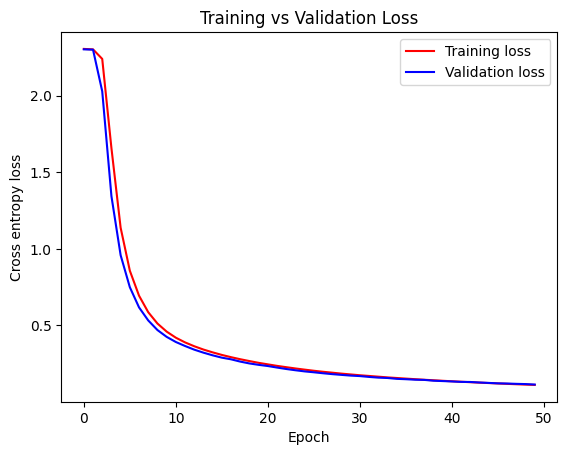

In [11]:
plt.plot(trainLosses, color='red', label='Training loss')
plt.plot(valLosses, color='blue', label='Validation loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross entropy loss')
plt.legend()
plt.show()

<h4>Evaluate on test data</h4>

In [12]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testLoader:
        outputs = model(images)
        values, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy = {100 * correct / total:.2f}%")

Test Accuracy = 96.68%


<h4>Examples of some images with their true and predicted labels</h4>

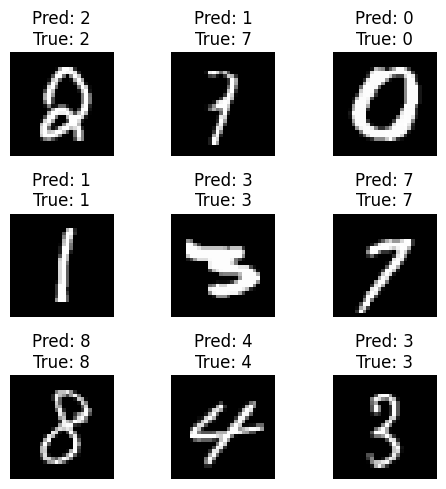

In [13]:
numImages = 9
random.seed(2)
testDataSize = len(testLoader.dataset)
indices = random.sample(range(testDataSize), numImages)

images = []
labels = []
for idx in indices:
    img, label = testLoader.dataset[idx]
    images.append(img)
    labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)

# Predict label
model.eval()
with torch.no_grad():
    outputs = model(images)
    values, predicted = torch.max(outputs, 1)

# Plot images along with true and predicted values
fig, axes = plt.subplots(3, 3, figsize=(5,5))
axes = axes.flatten()

for i in range(numImages):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(f'Pred: {predicted[i].item()}\nTrue: {labels[i].item()}')
    axes[i].axis('off')
plt.tight_layout()